# King / Queen на word-эмбеддингах: метрика concept-survival

Цели ноутбука:

1. Ввести **метрику concept-survival** — измеримый критерий «пережил ли *именованный*
   концепт операцию слияния», которого нет в стандартных бенчмарках merging.
2. Честно проверить на **реальных** эмбеддингах (GloVe Wikipedia + GloVe Twitter — две
   независимо обученные модели), что происходит с аналогией `king − man + woman ≈ queen`
   при разных способах слияния без обучения.

**Главный вывод (честный, в т.ч. как граница применимости):** на уровне word-эмбеддингов
концепт-аналогия **очень устойчива** — выживает даже при наивном усреднении и при слиянии
из разных систем координат. Значит, трудный режим, где способ слияния действительно важен,
лежит на уровне **весов глубокой модели** → ноутбук `03_kingqueen_distilgpt2.ipynb`.

> Воспроизводимо, CPU. Первая загрузка GloVe (~130 + ~390 МБ) кэшируется.

In [1]:
import numpy as np
from scipy.linalg import orthogonal_procrustes
import gensim.downloader as api
np.random.seed(0)

A_kv = api.load("glove-wiki-gigaword-100")   # модель A: Wikipedia+Gigaword
B_kv = api.load("glove-twitter-100")          # модель B: Twitter (другой корпус)
print("dim:", A_kv.vector_size)
print("A: king-man+woman ->", A_kv.most_similar(positive=['king','woman'],negative=['man'],topn=3))
print("B: king-man+woman ->", B_kv.most_similar(positive=['king','woman'],negative=['man'],topn=3))

dim: 100
A: king-man+woman -> [('queen', 0.7698541283607483), ('monarch', 0.6843381524085999), ('throne', 0.6755736470222473)]
B: king-man+woman -> [('queen', 0.7052315473556519), ('prince', 0.6666139364242554), ('mother', 0.6436765193939209)]


## 1. Рабочее пространство и метрика concept-survival

Общий словарь двух моделей; векторы L2-нормируем. Метрика в пространстве `S`:
строим `v = S[king] − S[man] + S[woman]`, смотрим (а) косинус с `S[queen]`,
(б) ранг `queen` среди ближайших соседей (исключая king/man/woman).
**rank = 1 и высокий косинус ⇒ концепт жив.**

In [2]:
ROYAL = ["king","queen","man","woman","royal","throne","monarch",
         "prince","princess","kingdom"]
shared = [w for w in A_kv.index_to_key[:30000] if w in B_kv.key_to_index]
VOCAB = shared[:20000]
for w in ROYAL:
    if w not in VOCAB: VOCAB.append(w)
idx = {w: i for i, w in enumerate(VOCAB)}

def l2(M): return M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-9)
A = l2(np.stack([A_kv[w] for w in VOCAB]).astype("float64"))
B = l2(np.stack([B_kv[w] for w in VOCAB]).astype("float64"))

def concept_survival(S, a="king", b="man", c="woman", target="queen"):
    S = l2(S)
    v = S[idx[a]] - S[idx[b]] + S[idx[c]]; v /= np.linalg.norm(v) + 1e-9
    sims = S @ v; order = np.argsort(-sims)
    exclude = {idx[a], idx[b], idx[c]}
    ranked = [i for i in order if i not in exclude]
    return {"cos_queen": round(float(v @ S[idx[target]]), 3),
            "rank_queen": ranked.index(idx[target]) + 1,
            "top3": [VOCAB[i] for i in ranked[:3]]}

print("модель A:", concept_survival(A))
print("модель B:", concept_survival(B))

модель A: {'cos_queen': 0.77, 'rank_queen': 1, 'top3': ['queen', 'monarch', 'throne']}
модель B: {'cos_queen': 0.705, 'rank_queen': 1, 'top3': ['queen', 'prince', 'mother']}


## 2. Слияние без обучения: наивное усреднение vs Procrustes vs разные системы координат

- **naive:** усреднить координаты как есть.
- **rotated frame:** модель B переведена случайным ортогональным поворотом в *другую*
  систему координат (имитация независимо обученной модели) — затем наивное усреднение.
- **Procrustes:** найти поворот, выравнивающий B к A по словам-якорям (training-free), и усреднить.

In [3]:
# B в другой системе координат
rng = np.random.default_rng(5)
Q, _ = np.linalg.qr(rng.standard_normal((100, 100)))
B_rot = B @ Q

# Procrustes-выравнивание B->A по случайным якорям
anchors = rng.choice(len(VOCAB), size=200, replace=False)
R, _ = orthogonal_procrustes(B_rot[anchors], A[anchors])
B_aligned = B_rot @ R

results = {
    "naive avg (A+B)/2":               concept_survival((A + B) / 2),
    "naive avg, B в другой системе":   concept_survival((A + B_rot) / 2),
    "Procrustes-выравнивание + avg":   concept_survival((A + B_aligned) / 2),
}
for k, v in results.items():
    print(f"{k:32} {v}")

naive avg (A+B)/2                {'cos_queen': 0.764, 'rank_queen': 1, 'top3': ['queen', 'prince', 'princess']}
naive avg, B в другой системе    {'cos_queen': 0.743, 'rank_queen': 1, 'top3': ['queen', 'prince', 'mother']}
Procrustes-выравнивание + avg    {'cos_queen': 0.789, 'rank_queen': 1, 'top3': ['queen', 'mother', 'prince']}


## 3. Сводка

In [4]:
import pandas as pd
rows = [("модель A (Wikipedia)", concept_survival(A)),
        ("модель B (Twitter)",   concept_survival(B))]
rows += [(k, v) for k, v in results.items()]
df = pd.DataFrame([{"вариант": n, **r} for n, r in rows])
df

,вариант,cos_queen,rank_queen,top3
0,модель A (Wikipedia),0.770,1,"[queen, monarch, throne]"
1,модель B (Twitter),0.705,1,"[queen, prince, mother]"
2,naive avg (A+B)/2,0.764,1,"[queen, prince, princess]"
3,"naive avg, B в другой системе",0.743,1,"[queen, prince, mother]"
4,Procrustes-выравнивание + avg,0.789,1,"[queen, mother, prince]"


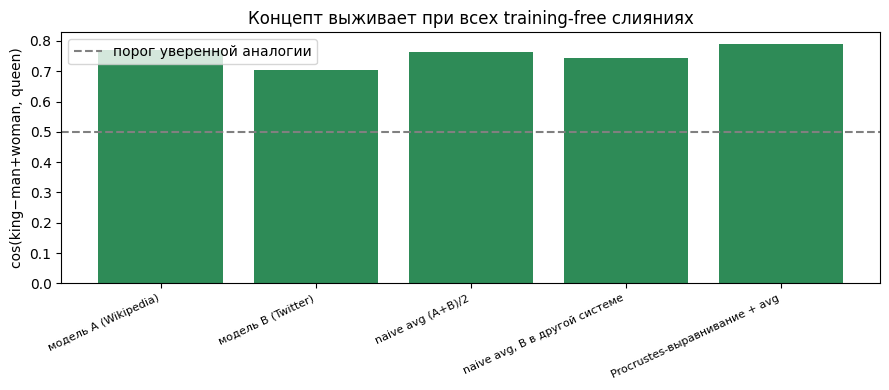

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(df["вариант"], df["cos_queen"], color="seagreen")
ax.axhline(0.5, ls="--", c="gray", label="порог уверенной аналогии")
ax.set_ylabel("cos(king−man+woman, queen)"); ax.set_title("Концепт выживает при всех training-free слияниях")
ax.tick_params(axis="x", rotation=25)
for t in ax.get_xticklabels(): t.set_ha("right"); t.set_fontsize(8)
ax.legend(); plt.tight_layout(); plt.show()

## 4. Выводы

- **Метрика concept-survival** делает измеримым то, чего нет в обычных бенчмарках слияния:
  пережил ли конкретный *named*-концепт операцию.
- **Честный результат:** на уровне word-эмбеддингов аналогия king/queen чрезвычайно
  устойчива — `queen` остаётся соседом #1 даже после наивного усреднения, усреднения из
  разных систем координат и Procrustes-выравнивания. Концепт-якорение (CAM) здесь **не
  даёт значимого выигрыша** — концепт и так не теряется. Это важная **граница применимости**.
- Следствие: интересный режим, где способ слияния *действительно* решает судьбу концепта, —
  это **веса глубокой модели**, где у двух специалистов веса конфликтуют. Туда и переходим:
  `03_kingqueen_distilgpt2.ipynb` (реальная LLM, слияние весов, perplexity на обоих концептах).